# Projected Gradient Descent and Frank-Wolfe for Constrained Optimization

This notebook demonstrates two classical approaches to **constrained optimization**: projected gradient descent (PGD) and the Frank-Wolfe (conditional gradient) method. We apply both to a least-squares problem with an $\ell_1$-ball constraint, motivated by sparse signal recovery. The learning objectives are:

- Understand the difference between penalized (Lasso) and constrained formulations of sparse optimization.
- Implement **projected gradient descent** with projection onto the $\ell_1$-ball.
- Implement the **Frank-Wolfe** algorithm using a linear minimization oracle over the $\ell_1$-ball.
- Compare the two methods in terms of convergence, sparsity, and reconstruction quality.

---

## Mathematical Background

### Constrained Formulation

We consider the constrained problem

$$
\min_{\beta}\; \frac{1}{n}\|y - X\beta\|_2^2 \quad \text{subject to} \quad \|\beta\|_1 \leq \lambda.
$$

This is equivalent to the Lagrangian (Lasso) formulation for a suitable choice of regularization parameter.

### Projected Gradient Descent (PGD)

PGD alternates between a gradient step and a projection back onto the constraint set $\mathcal{C} = \{\beta : \|\beta\|_1 \leq \lambda\}$:

$$
\beta^{k+1} = \Pi_{\mathcal{C}}\!\bigl(\beta^k - \alpha\,\nabla f(\beta^k)\bigr),
$$

where $\Pi_{\mathcal{C}}(x) = \arg\min_{z \in \mathcal{C}} \|z - x\|_2$ is the Euclidean projection. For the $\ell_1$-ball, this projection can be computed in $O(p \log p)$ time via sorting.

### Frank-Wolfe (Conditional Gradient) Method

Frank-Wolfe avoids explicit projection by instead solving a **linear minimization** over $\mathcal{C}$ at each step:

$$
s^k = \arg\min_{s \in \mathcal{C}}\; \nabla f(\beta^k)^\top s, \qquad \beta^{k+1} = \beta^k + \gamma_k(s^k - \beta^k).
$$

For the $\ell_1$-ball, the linear minimization oracle has a simple closed form: $s^k$ is a vertex of the $\ell_1$-ball, i.e., $s^k = \pm\lambda\, e_j$ where $j = \arg\max_i |[\nabla f(\beta^k)]_i|$. This is cheaper per iteration than PGD (no sorting required), but Frank-Wolfe typically converges more slowly ($O(1/k)$ for the objective gap).

## Problem Setup

We consider the $\ell_1$-constrained least-squares problem

$$\min_\beta \;\frac{1}{n}\|y - X\beta\|_2^2 \quad \text{subject to} \quad \|\beta\|_1 \leq \lambda.$$

We implement and compare two methods:
- **Projected gradient descent (PGD):** takes a gradient step, then projects back onto the $\ell_1$-ball.
- **Frank-Wolfe (conditional gradient):** solves a linear minimization over the $\ell_1$-ball at each step instead of projecting.

# Data Preparation

- Create a Simple Object: We start by creating a 128x128 image with a small circle at the center to serve as our object of interest. This image is then vectorized and used as the signal.

- Vectorization: The 2D image matrix of the object is then flattened into a 1D vector to facilitate mathematical operations.

- Structured Transformation: A structured matrix, designed to simulate sparse projections by mimicking data collection at different angles or frequencies, is used to transform the object vector. This step abstracts the concept of taking projections from various perspectives.

- Projections: Transform the singal using the structed matrix.

- Add Noise: Gaussian noise with a specified standard deviation is added to the projections to simulate the real-world scenario where measurements are affected by noise. This step enhances the realism of the simulation by accounting for the inevitable presence of noise in actual data collection processes.

Our goal later is to reconstruct the signal (object) from data --- $X $ is the structed matrix and $y$ is the noisy version of projections.

## Projection onto the $\ell_1$-Ball and PGD Implementation

### $\ell_1$-ball projection algorithm

Given a vector $x$ and radius $\lambda$, the projection $\Pi_{\|\cdot\|_1 \leq \lambda}(x)$ is computed as follows:

1. **Sort** the absolute values $|x|_{(1)} \geq |x|_{(2)} \geq \cdots \geq |x|_{(n)}$.
2. **Find** the largest index $k$ such that $\sum_{i=1}^{k}|x|_{(i)} - k\cdot|x|_{(k)} \leq \lambda$.
3. **Compute threshold** $\theta = \frac{1}{k}\bigl(\sum_{i=1}^{k}|x|_{(i)} - \lambda\bigr)$.
4. **Soft-threshold** each entry: $[\Pi(x)]_i = \mathrm{sign}(x_i)\max(|x_i| - \theta, 0)$.

This is essentially the same soft-thresholding idea as in proximal gradient, but the threshold $\theta$ is computed to satisfy the constraint $\|\Pi(x)\|_1 = \lambda$ exactly.

**Reference:** Duchi, Shalev-Shwartz, Singer, and Chandra, *Efficient Projections onto the $\ell_1$-Ball*, ICML 2008.

# Optimization objective: Least-squares + $\ell_1$-constraint
$$
\min_{\beta} \frac{1}{n} \| y - X \beta \|_2^2  ~~\textrm{subject to}~~  \|\beta\|_1 \leq \lambda.  
$$
This objective is not smooth. We compare two methods:

- (a) projected gradient descent: directly call gradient from automatic differentiation, run constant-stepsize gradient descent, project it.
- (b) Frank-Wolfe: search a descent direction, update.

## Projection to $\ell_1$-ball:

- Sort the absolute values of the elements of $x$ in decreasing order. Let $|x|_{(1)}, |x|_{(2)}, \ldots, |x|_{(n)}$ denote these sorted absolute values, such that $|x|_{(1)} \geq |x|_{(2)} \geq \cdots \geq |x|_{(n)}$.
    
-Find the largest $k \in \{1, \ldots, n\}$ such that
  $$
    \sum_{i=1}^{k} |x|_{(i)} - k \cdot |x|_{(k)} \leq \lambda.
$$
    This step identifies the threshold index \(k\) for which the cumulative sum of the largest \(k\) absolute values, adjusted by the subtraction of \(k\) times the \(k\)-th largest absolute value, first exceeds \(\lambda\).
    
- Compute the threshold $\theta$ as
  $$
    \theta = \frac{1}{k} \left( \sum_{i=1}^{k} |x|_{(i)} - \lambda \right).
$$
    The threshold $\theta$ is used to adjust the magnitude of the elements in $x$ for the projection.
    
-  The projected vector is then obtained by applying the following operation to each element $x_i$ of $x$:
 $$
    \text{proj}_{\ell_1}(x_i) = \text{sign}(x_i) \cdot \max(|x_i| - \theta, 0).
  $$
    This operation reduces the magnitude of each element by $\theta$, preserving the sign of the original elements, and ensuring that the result lies within the \(\ell_1\)-ball of radius $\lambda$.

Reference:
https://stanford.edu/~jduchi/projects/DuchiShSiCh08.pdf



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Create a 128x128 image with a small circle at the center ---
N = 128
object_img = np.zeros((N, N))
center = N // 2
radius = 10
for i in range(N):
    for j in range(N):
        if (i - center) ** 2 + (j - center) ** 2 <= radius ** 2:
            object_img[i, j] = 1.0

# Vectorize the image to get the true signal
beta_true = object_img.flatten()

# --- Structured transformation matrix (simulates sparse projections) ---
np.random.seed(42)
m = 3000  # number of measurements (projections)
p = N * N  # dimension of the signal
X = np.random.randn(m, p) / np.sqrt(m)

# --- Generate noisy projections ---
noise_std = 0.01
y = X @ beta_true + noise_std * np.random.randn(m)

print(f"Image size: {N}x{N},  signal dimension: {p}")
print(f"Number of measurements: {m}")
print(f"True signal l1-norm: {np.linalg.norm(beta_true, 1):.2f}")
print(f"True signal l2-norm: {np.linalg.norm(beta_true, 2):.2f}")

# Display the original object
plt.figure(figsize=(4, 4))
plt.imshow(object_img, cmap='gray')
plt.title('Original Object (128x128)')
plt.axis('off')
plt.show()

regularization parameter is 2500.0
iteration   1 | objective value 40571.1559
iteration  11 | objective value 1600.9323
iteration  21 | objective value 312.3818
iteration  31 | objective value 159.9337
iteration  41 | objective value 101.1713
iteration  51 | objective value 68.1989
iteration  61 | objective value 47.8261
iteration  71 | objective value 34.4727
iteration  81 | objective value 25.3676
iteration  91 | objective value 18.9683
iteration 101 | objective value 14.3700
iteration 111 | objective value 10.9975
iteration 121 | objective value 8.4912
iteration 131 | objective value 6.6048
iteration 141 | objective value 5.1713
iteration 151 | objective value 4.0733
iteration 161 | objective value 3.2245
iteration 171 | objective value 2.5643
iteration 181 | objective value 2.0474
iteration 191 | objective value 1.6405
Estimation error is 59.6015


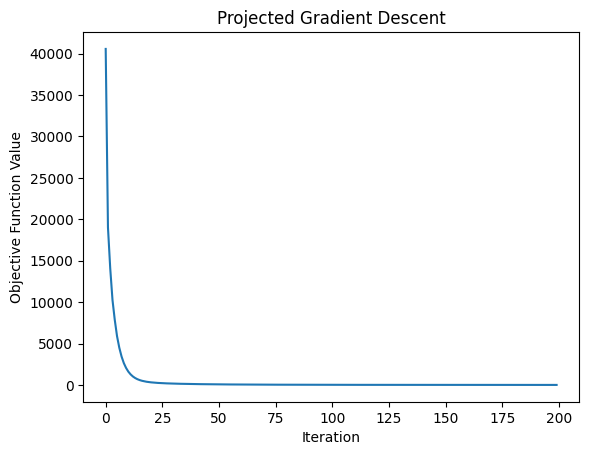

(-0.5, 49.5, 49.5, -0.5)

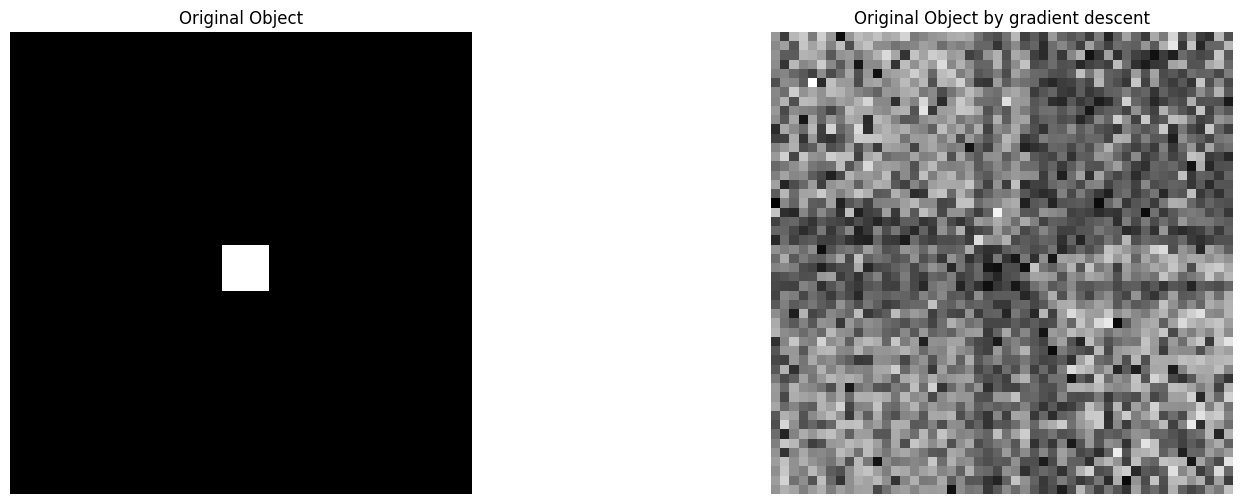

In [7]:
import numpy as np

def project_to_l1_ball(x, lambda_val):
    """
    Project the vector x onto the l1-ball of radius lambda_val.

    Parameters:
    - x: np.array, the vector to be projected.
    - lambda_val: float, the radius of the l1-ball.

    Returns:
    - np.array, the projected vector.
    """
    # Step 1: Sort the absolute values in decreasing order
    abs_x_sorted = np.sort(np.abs(x))[::-1]
    # Compute the cumulative sum of abs_x_sorted
    cumsum_abs_x_sorted = np.cumsum(abs_x_sorted)

    # Step 2: Find the largest k such that the condition holds
    rho = np.nonzero(abs_x_sorted * np.arange(1, len(x) + 1) > (cumsum_abs_x_sorted - lambda_val))[0][-1]

    # Step 3: Compute the threshold theta
    theta = (cumsum_abs_x_sorted[rho] - lambda_val) / (rho + 1)

    # Step 4: Compute the projected vector
    projected_x = np.sign(x) * np.maximum(np.abs(x) - theta, 0)

    return projected_x



def projected_gradient_descent(y, X, beta_0, stepsize, num_iterations, lambda_val):
    beta = beta_0
    function_values = []
    violation = False
    m,n = np.shape(X)


    for t in range(num_iterations):
        # Compute gradient
        grad = -2 * X.T.dot(y - X @ beta) / m

        # Gradient descent step
        beta_temp = beta - stepsize * grad

        # Projection onto l1-ball

        beta = project_to_l1_ball(beta_temp, lambda_val)
        if np.linalg.norm(beta, 1) > (lambda_val + 1e-3):
            violation = True
            print("constraint is violated")
        # Record the function value
        function_values.append(np.linalg.norm(y- X @ beta)**2 / (2*m))

    return beta, function_values


beta_0 = np.zeros(X.shape[1])
lambda_0 = 100 * np.linalg.norm(beta_true, 1)
stepsize = 0.01
num_iterations = 200

print(f"regularization parameter is {lambda_0}")
final_beta, function_values = projected_gradient_descent(y, X, beta_0, stepsize, num_iterations, lambda_0)

error = np.linalg.norm(final_beta - beta_true)


for i, value in enumerate(function_values):
    if (i+1) % 10 == True:
        print(f"iteration{i + 1:4d} | objective value {value:.4f}")

print(f"Estimation error is {error:.4f}")


# Visualize the objective function value over iterations
plt.plot(function_values)
plt.xlabel('Iteration')
plt.ylabel('Objective Function Value')
plt.title('Projected Gradient Descent')
plt.show()



# plot the estimated signal
estimated_image = final_beta.reshape(N, N)
original_image = beta_true.reshape(N, N)

plt.figure(figsize=(18, 6))

# Original Object
plt.subplot(1, 2, 1)
plt.imshow(object_img, cmap='gray')

plt.title('Original Object')
plt.axis('off')

# Structured Matrix Visualization (Simplified)
plt.subplot(1, 2, 2)
plt.imshow(estimated_image, cmap='gray')
plt.title('Original Object by gradient descent')
plt.axis('off')




## Frank-Wolfe Implementation

### Linear minimization oracle for the $\ell_1$-ball

At each iteration, Frank-Wolfe solves $s^k = \arg\min_{s:\|s\|_1 \leq \lambda} \nabla f(\beta^k)^\top s$. For the $\ell_1$-ball, the solution is a **vertex** of the ball:

$$
s^k = -\lambda\,\mathrm{sign}\bigl([\nabla f(\beta^k)]_j\bigr)\,e_j, \quad \text{where } j = \arg\max_i\bigl|[\nabla f(\beta^k)]_i\bigr|.
$$

This is an $O(p)$ operation (just finding the argmax), compared to the $O(p\log p)$ projection in PGD. The trade-off is that Frank-Wolfe converges more slowly and its iterates tend to be sparse by construction (each update adds weight to at most one new coordinate).

Descent Direction in Frank-Wolfe
To compute the descent direction in the Frank-Wolfe algorithm, given a gradient vector, we find the point in the constraint set that has the maximum alignment (in terms of the dot product) with the negative gradient. For the
$\ell_1$-norm constraint set, this corresponds to selecting a vertex of the $\ell_1$-ball.


In [ ]:
import numpy as np

def frank_wolfe_descent_direction(grad, lambda_val):
    """
    Compute the descent direction for the Frank-Wolfe algorithm.

    Parameters:
    - grad: np.array, the gradient vector of the objective at the current point.
    - lambda_val: float, the radius of the l1-ball (constraint).

    Returns:
    - s: np.array, the descent direction vector.
    """
    s = np.zeros_like(grad)
    index = np.argmax(np.abs(grad))  # Find the index of the largest magnitude in grad
    s[index] = -np.sign(grad[index]) * lambda_val  # Assign +/-lambda_val opposite to grad sign
    return s


def frank_wolfe(y, X, beta_0, stepsize, num_iterations, lambda_val):
    beta = beta_0
    function_values = []
    m,n = np.shape(X)
    for t in range(num_iterations):
        # Compute the gradient of the objective function at the current beta
        grad = -2 * X.T.dot(y - X.dot(beta)) / m

        # Compute the descent direction using the Frank-Wolfe method
        s = frank_wolfe_descent_direction(grad, lambda_val)

        # Update beta using the computed direction and step size
        gamma = 2 / (t + 2) if stepsize is None else stepsize  # Example step size rule
        beta = (1 - gamma) * beta + gamma * s

        # Record the current value of the objective function
        function_values.append(np.linalg.norm(y - X.dot(beta))**2 / (2*m))

    return beta, function_values

## Bonus: Solving the Same Data with the Penalized (Lasso) Formulation

For comparison, we can also solve the **penalized** version of the problem $\min_\beta \frac{1}{2n}\|y - X\beta\|_2^2 + \lambda\|\beta\|_1$ using subgradient descent and proximal gradient descent (as implemented in the previous notebook). This allows us to compare the constrained and penalized approaches on the same data.

### Subgradient descent for the Lasso penalty formulation

We re-use the subgradient descent implementation from the previous notebook. Recall that the step size must decay (e.g., $\alpha^t = c/\sqrt{t}$) for convergence.

## Subgradient descent

### Proximal gradient descent for the Lasso penalty formulation

Proximal gradient descent applies the soft-thresholding operator after each gradient step on the smooth least-squares part. It typically converges faster than subgradient descent.

## proximal gradient

In [12]:
import torch

def least_squares_loss(X, y, beta):
    """
    Compute the least squares loss function.

    Parameters:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - beta: weight vector of shape (d,)

    Returns:
    - loss: least squares loss value
    """
    n = X.shape[0]
    mse_loss = torch.mean((X @ beta - y) ** 2)
    loss = 0.5 * mse_loss
    return loss

def soft_thresholding(x, threshold):
    """
    Soft thresholding operator.

    Parameters:
    - x: input tensor
    - threshold: threshold value

    Returns:
    - soft_thresholded_x: soft thresholded tensor
    """
    return torch.sign(x) * torch.max(torch.abs(x) - threshold, torch.zeros_like(x))

def proximal_gradient_descent(X, y, beta_init=None, lambd=2, stepsize=0.1, max_iter=1000):
    """
    Proximal gradient descent algorithm for Lasso.

    Parameters:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - beta_init: initial weight vector of shape (d,) (default: all-zero vector)
    - lambd: regularization parameter (default: 0.1)
    - stepsize: step size (default: 0.1)
    - max_iter: maximum number of iterations (default: 1000)

    Returns:
    - beta: final weight vector of shape (d,)
    - func_values: sequence of function values
    """
    n, d = X.shape
    if beta_init is None:
        beta = torch.zeros(d, requires_grad=True)
    else:
        beta = beta_init.clone().detach().requires_grad_(True)

    func_values = []

    for t in range(max_iter):
        loss = least_squares_loss(X, y, beta)
        loss.backward()

        with torch.no_grad():
            beta_temp = beta.clone().detach() - stepsize * beta.grad
            beta_temp = soft_thresholding(beta_temp, stepsize * lambd)
            beta.copy_(beta_temp)

            beta.grad.zero_()

        func_value = least_squares_loss(X, y, beta) + lambd * torch.sum(torch.abs(beta))
        func_values.append(func_value.item())

    return beta.detach(), func_values

In [ ]:

beta_0 = torch.zeros(X.shape[1], dtype=torch.float32)
lambd = 0.2
stepsize = 0.1
num_iterations = 400

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

beta_sub_decay, fun_sub_decay = proximal_gradient_descent(X, y, beta_0, lambd, stepsize, num_iterations)


error = np.linalg.norm(beta_sub_decay - beta_true)


for i, value in enumerate(fun_sub_decay):
    if (i+1) % 10 == True:
        print(f"iteration{i + 1:4d} | objective value {value:.4f}")

print(f"Estimation error is {error:.4f}")


# Visualize the objective function value over iterations
plt.plot(fun_sub_decay)
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.title('Proximal Gradient Descent (Lasso)')
plt.show()



# plot the estimated signal
estimated_image = beta_sub_decay.reshape(N, N)
original_image = beta_true.reshape(N, N)

plt.figure(figsize=(18, 6))

# Original Object
plt.subplot(1, 2, 1)
plt.imshow(object_img, cmap='gray')

plt.title('Original Object')
plt.axis('off')

# Structured Matrix Visualization (Simplified)
plt.subplot(1, 2, 2)
plt.imshow(estimated_image, cmap='gray')
plt.title('Original Object by proximal gradient descent')
plt.axis('off')


## Summary

This notebook explored two fundamental approaches to constrained optimization over the $\ell_1$-ball:

| Method | Per-iteration cost | Convergence rate | Sparsity of iterates |
|--------|-------------------|-----------------|---------------------|
| **Projected Gradient Descent** | $O(p\log p)$ (sorting for projection) | $O(1/k)$ | Sparse after projection |
| **Frank-Wolfe** | $O(p)$ (argmax for linear oracle) | $O(1/k)$ | Naturally sparse (vertex updates) |

**Key takeaways:**

- **PGD** requires projecting onto the $\ell_1$-ball at every step, which involves sorting and soft-thresholding. It converges relatively quickly and produces high-quality reconstructions.
- **Frank-Wolfe** replaces projection with a cheap linear minimization oracle (finding the coordinate with the largest gradient magnitude). Its iterates are sparse by construction since each step moves toward a vertex of the $\ell_1$-ball, but it may converge more slowly.
- The **constraint radius $\lambda$** plays a critical role: setting $\lambda$ close to $\|\beta^*\|_1$ gives the best reconstruction, while a loose constraint ($\lambda \gg \|\beta^*\|_1$) provides little regularization.
- Both the constrained formulation (this notebook) and the penalized Lasso formulation (previous notebook) solve the same underlying statistical problem. The choice between them depends on whether it is more natural to specify a constraint budget or a regularization strength.